![image.png](https://i.imgur.com/a3uAqnb.png)

# **⚡ Wind Turbine Object Detection with RT-DETR**
In this lab, we will:
✅ **Use RT-DETR** for **wind turbine detection**  
✅ **Understand the dataset structure**  
✅ **Train a RT-DETR model**  
✅ **Evaluate the model on the validation set**  
✅ **Run inference on test images**  

---

## **1️⃣ Understanding the Dataset Structure**
The dataset follows the **RT-DETR format**, which consists of:
📂 **train/** → Training images & labels  
📂 **valid/** → Validation images & labels  
📂 **test/** → Test images (for inference)  
📜 **data.yaml** → Defines dataset paths & class names  

### **🔹 DETR Dataset Folder Structure**
```
drone_dataset/
│── train/
│   │── images/
│   │   ├── pic_031.jpg
│   │   ├── pic_032.jpg
│   │   ├── ...
│   │── labels/
│   │   ├── pic_031.txt
│   │   ├── pic_032.txt
│   │   ├── ...
│
│── valid/
│   │── images/
│   │   ├── pic_035.jpg
│   │   ├── pic_036.jpg
│   │   ├── ...
│   │── labels/
│   │   ├── pic_035.txt
│   │   ├── pic_036.txt
│   │   ├── ...
│
│── test/
│   │── images/
│   │   ├── pic_040.jpg
│   │   ├── pic_041.jpg
│   │   ├── ...
│   │── labels/
│   │   ├── pic_040.txt
│   │   ├── pic_041.txt
│   │   ├── ...
│
│── data.yaml
```
Each **image** has a **corresponding label** file with the **same name**, but a `.txt` extension.

---

## **2️⃣ What’s Inside a RT-DETR Label File?**
Each `.txt` file contains **annotations** in this format:

```
<class_id> <x_center> <y_center> <width> <height>
```

✅ **All values are normalized** between **0 and 1**  
✅ The **bounding box** is defined by its **center** and **size**  

### **🔹 Example (`pic_031.txt`)**
```
0 0.526 0.448 0.12 0.15
1 0.731 0.602 0.18 0.22
```
- **First column** → Class ID (`0` = cable tower, `1` = turbine)  
- **Rest** → Bounding box (normalized)  

---

## **3️⃣ Loading the Dataset**

In [ ]:
# # Please uncomment this out when you are running this lab on google colab!
# import os

# # Set KaggleHub cache to a directory inside /content/
# os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [ ]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("kylegraupe/wind-turbine-image-dataset-for-computer-vision")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/wind-turbine-image-dataset-for-computer-vision


In [ ]:
# Load dataset configuration
dataset_path = path + "/data.yaml"

# Check dataset information
print(open(dataset_path).read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['cable tower', 'turbine']

roboflow:
  workspace: kyle-graupe-jobhn
  project: wind-farms
  version: 5
  license: CC BY 4.0
  url: https://universe.roboflow.com/kyle-graupe-jobhn/wind-farms/dataset/5


## **4️⃣ Training a DETR Model**
We will fine-tune a **pretrained DETR model**.

In [ ]:
# Install Ultralytics library which has RT-DETR
!pip install -q ultralytics

In [ ]:
from ultralytics import RTDETR
import matplotlib.pyplot as plt
# Load RT-DETR model (Large version)
model = RTDETR("rtdetr-l.pt")

#### Let's try to predict an image before training


image 1/1 /kaggle/input/wind-turbine-image-dataset-for-computer-vision/test/images/windmill1_jpg.rf.35f47a69d0373596edb7578eea5151f6.jpg: 640x640 1 bench, 2 birds, 3 cows, 69.7ms
Speed: 14.5ms preprocess, 69.7ms inference, 20.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict


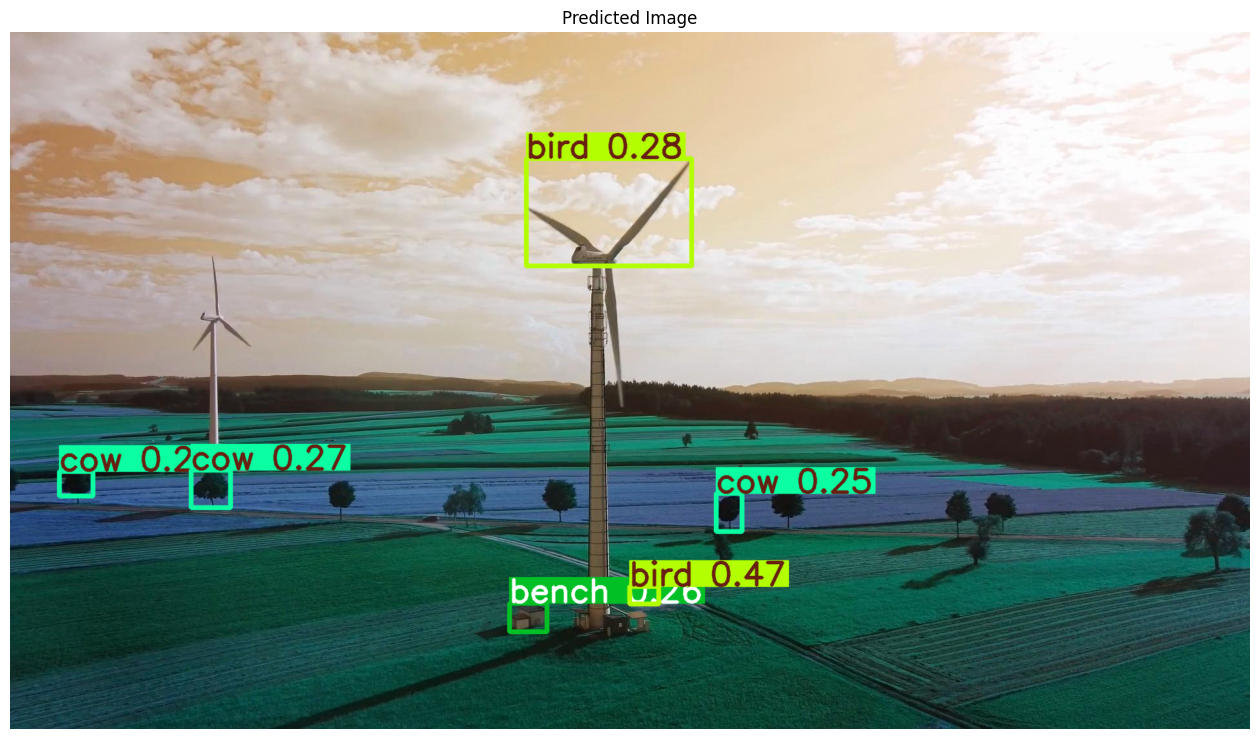

In [ ]:
# Load an image and run inference
results = model(path + "/test/images/windmill1_jpg.rf.35f47a69d0373596edb7578eea5151f6.jpg", save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(16, 16))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")
plt.show()


## OMG, AI will take over the world.🫠



#### Nevermind, let's train it! 🚀

In [ ]:
# Train on the wind turbine dataset


## **5️⃣ Evaluating the Model**
We use **mAP@0.5:0.95** to assess performance.

In [ ]:
# Run validation


## **6️⃣ Running Inference on Test Images**


In [ ]:
# Load an image and run inference



### 🚀 **Now you have a working DETR object detection pipeline for wind turbines!**

![image.png](https://i.imgur.com/rGGLEsK.png)

### Contributed by: Abdulrahman Alfrihidi